In [1]:
# load libraies

%run py_libraries.py

/Users/4476224/.local/lib/python3.8/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.6.0 and strictly below 2.9.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


In [2]:
# loading utility files

from utility.sv_fig import savefig
from utility.mi_score import MI_score



In [3]:
# def savefig(filename, crop = True):
#     plt.savefig('{}.pdf'.format(filename))

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_row', None)

# load data
# X_train = pd.read_csv('data/norm_X_train_NCa_Ca.csv')
# y_train = pd.read_csv('data/y_train_NCa_Ca.csv')

data = pd.read_csv('data/Xy_NCa_PCa_md.csv')

print(data.shape)

(56, 38)


In [5]:
# MI

# Data
X = data.drop(columns=['CACHEXSTAGE0VIG'])
y = data['CACHEXSTAGE0VIG']

mi_scores = MI_score(X,y)

mi_df = pd.DataFrame(
    {
        "MI_mean": mi_scores.mean(axis=0),
        "MI_std": mi_scores.std(axis=0),
    },
    index=X.columns
).sort_values("MI_mean", ascending=False)

print("\n Cross-Validated Mutual Information Feature Ranking ")
print(mi_df.round(10))


 Cross-Validated Mutual Information Feature Ranking 
               MI_mean    MI_std
MIP.3a        0.155050  0.035434
CRP           0.117720  0.036737
Leptin        0.103521  0.069265
GRO.a         0.101656  0.053304
MDC           0.079613  0.043706
HGF           0.074053  0.054941
Adiponectin   0.048047  0.057468
G.CSF         0.045977  0.037157
ENA.78        0.040926  0.036582
CA19.9        0.037935  0.032749
HbA1c         0.035003  0.026173
GDF.15        0.032165  0.033383
IL.10         0.031959  0.042962
ZAG           0.031621  0.029464
CCK           0.031383  0.027716
TGF.B2        0.030981  0.018818
C.peptide     0.026509  0.021106
Insulin       0.023483  0.020127
PPAR.y        0.023104  0.046207
MIP.1a        0.021561  0.011442
IL.8          0.020969  0.028527
Laminin       0.020000  0.019399
TGF.B1        0.019644  0.019931
MMP.2         0.014054  0.020658
TNF.a         0.012776  0.024722
HIF.1a        0.010879  0.011296
Glucose       0.009505  0.012809
Triglyceride  0.007031

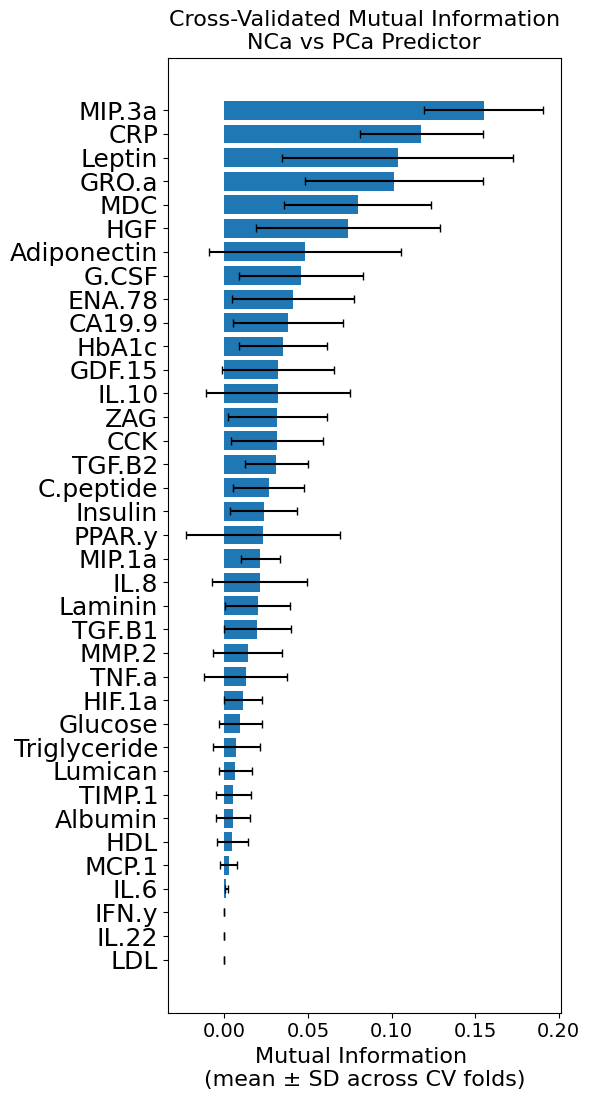

In [6]:
# Plot CV Mutual Information (mean ± std)
mi_plot = mi_df.sort_values("MI_mean")

plt.figure(figsize=(6, max(4, 0.3 * len(mi_plot))))

# plt.barh(
#     mi_plot.index,
#     mi_plot["MI_mean"],
#     xerr=mi_plot["MI_std"],
#     capsize=3
# )

plt.barh(
    mi_plot.index,
    mi_plot["MI_mean"],
    xerr=mi_plot["MI_std"],
    capsize=3
)

plt.yticks(fontsize=18)
plt.xticks(fontsize=14) 

plt.xlabel("Mutual Information \n(mean ± SD across CV folds)", fontsize=16)
plt.title("Cross-Validated Mutual Information\nNCa vs PCa Predictor", fontsize=16)
plt.tight_layout()

savefig("./figs/NCa_PCa_MI",dpi=1200,quality=100)
# plt.show()
